# Power Grid Frequency Regulation — MARL + Control Systems
### Multi-Agent Reinforcement Learning replacing classical droop/PI/AGC controllers

---

## Project Summary

Each generator in a power grid is one **MARL agent**. When load changes, frequency deviates from 60 Hz.
Classical controllers (Droop, PI, AGC) react with static rules. This project **replaces them with learned GNN policies**
where agents communicate over the physical power line topology.

| MARL Concept | Power Grid Meaning |
|---|---|
| **Agents** | Each generator (4 by default) |
| **Observation** | [ω, δ, Pe, Pm, load] — 5D local state |
| **Action** | ΔPm — continuous setpoint change |
| **Reward** | −\|ω\|/2 − 0.05\|ΔPm\|/0.1 (scaled) |
| **Communication** | GNN over physical grid topology graph |
| **Algorithm** | MAPPO (Multi-Agent PPO) |

## Notebook Sections
1. Imports & Setup
2. Physics & Environment (Swing Equation)
3. Classical Control Baselines (Droop, PI, AGC)
4. GNN Layers (GCN, GAT, Dynamic)
5. MARL Policies
6. Training Infrastructure (Buffer + MAPPO)
7. Train All Models
8. Results & Comparison Plots
9. Step Disturbance Response Test
10. Summary


## 1. Imports & Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.optim import Adam
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from gymnasium import spaces
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cuda | PyTorch: 2.10.0+cu128


## 2. Physics & Environment

### The Swing Equation

$$M_i \\frac{d\\omega_i}{dt} = P_{m,i} - P_{e,i} - D_i\\omega_i - P_{load,i}$$

| Symbol | Meaning | Controlled? |
|---|---|---|
| $\\omega_i$ | Frequency deviation — **target: 0** | No |
| $M_i$ | Inertia constant (like mass) | No |
| $D_i$ | Damping coefficient | No |
| $P_{m,i}$ | Mechanical power — **the action** | **Yes** |
| $P_{e,i}$ | Electrical power (from coupling) | No |
| $P_{load,i}$ | Load disturbance (uncontrollable) | No |

### Generator Coupling (DC Power Flow)
$$P_{e,i} = \\sum_j B_{ij}(\\delta_i - \\delta_j)$$

This coupling means one generator's angle change affects all neighbors — agents must communicate.

### Analogy: Mass-Spring-Damper
$$m\\ddot{x} = F_{input} - kx - c\\dot{x}$$
Swing equation IS a mass-spring-damper: $M$=mass, $D$=damper, $B_{ij}$ coupling=spring.

In [2]:
class PowerGridEnv(gym.Env):
    """
    Multi-Agent Power Grid Frequency Regulation — OpenAI Gym compatible.
    Swing Equation + DC Power Flow + Governor Dynamics.
    Observation: [omega, delta, Pe, Pm, load_disturbance] per generator.
    Action: delta_Pm (continuous [-0.1, 0.1] pu)
    Reward: scaled to [-1, 0] range to stabilize value function targets.
    """
    def __init__(self, n_generators=4, dt=0.01, max_steps=500,
                 topology='ring', disturbance_std=0.05, seed=None):
        super().__init__()
        self.n_generators = n_generators
        self.dt = dt; self.max_steps = max_steps
        self.disturbance_std = disturbance_std
        self.M     = np.ones(n_generators) * 10.0
        self.D     = np.ones(n_generators) * 1.0
        self.P_max = np.ones(n_generators) * 1.0
        self.P_min = np.zeros(n_generators)
        self.P_nom = np.ones(n_generators) * 0.5
        self.T_gov = np.ones(n_generators) * 0.1
        self.B     = self._build_susceptance(topology, n_generators)
        self.obs_dim = 5
        self.observation_space = spaces.Box(-np.inf, np.inf,
                                            shape=(n_generators, self.obs_dim), dtype=np.float32)
        self.action_space = spaces.Box(-0.1, 0.1, shape=(n_generators,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)

    def _build_susceptance(self, topology, n):
        B = np.zeros((n, n)); b = 5.0
        if topology == 'ring':
            for i in range(n): j=(i+1)%n; B[i,j]=b; B[j,i]=b
        elif topology == 'mesh':
            for i in range(n):
                for j in range(i+1,n): B[i,j]=b; B[j,i]=b
        elif topology == 'star':
            for i in range(1,n): B[0,i]=b; B[i,0]=b
        for i in range(n): B[i,i]=-np.sum(B[i,:])
        return B

    def _compute_Pe(self):
        Pe = np.zeros(self.n_generators)
        for i in range(self.n_generators):
            for j in range(self.n_generators):
                if i!=j and self.B[i,j]!=0:
                    Pe[i] += self.B[i,j]*(self.delta[i]-self.delta[j])
        return Pe

    def _get_obs(self):
        return np.stack([self.omega,self.delta,self.Pe,
                         self.Pm,self.load_dist],axis=1).astype(np.float32)

    def reset(self, seed=None, options=None):
        if seed is not None: self.rng = np.random.default_rng(seed)
        self.omega = self.rng.normal(0,0.01,self.n_generators)
        self.delta = self.rng.normal(0,0.01,self.n_generators)
        self.Pm    = self.P_nom.copy()
        self.Pe    = self._compute_Pe()
        self.load_dist = self.rng.normal(0,self.disturbance_std,self.n_generators)
        self.step_count = 0
        self.disturbance_event = None
        if self.rng.random() < 0.5:
            t_event = self.rng.integers(50, 200)
            g_event = self.rng.integers(0, self.n_generators)
            mag = self.rng.uniform(0.1, 0.25)
            self.disturbance_event = (t_event, g_event, mag)
        return self._get_obs(), {}

    def step(self, actions):
        actions = np.clip(actions, -0.1, 0.1)
        Pm_ref  = np.clip(self.Pm + actions, self.P_min, self.P_max)
        self.Pm += (self.dt/self.T_gov)*(Pm_ref - self.Pm)
        self.load_dist += self.rng.normal(0,0.005,self.n_generators)
        self.load_dist  = np.clip(self.load_dist,-0.5,0.5)
        # inject disturbance during training
        if self.disturbance_event is not None:
            t_event, g_event, mag = self.disturbance_event
            if self.step_count == t_event:
                self.load_dist[g_event] += mag
        # Swing equation integration
        self.Pe = self._compute_Pe()
        w0 = 2*np.pi*60
        dw = (1/self.M)*(self.Pm - self.Pe - self.D*self.omega - self.load_dist)
        self.omega = np.clip(self.omega + self.dt*dw, -2.0, 2.0)
        self.delta = np.clip(self.delta + self.dt*w0*self.omega, -np.pi, np.pi)
        # Scaled rewards: keep targets in [-1, 0]
        rewards = (-np.abs(self.omega)/2.0 - 0.05*np.abs(actions)/0.1)
        self.step_count += 1
        info = {'mean_freq_dev': np.mean(np.abs(self.omega)),
                'max_freq_dev':  np.max(np.abs(self.omega))}
        return self._get_obs(), rewards, False, self.step_count>=self.max_steps, info

    def get_adjacency(self):
        src,dst=[],[]
        for i in range(self.n_generators):
            for j in range(self.n_generators):
                if i!=j and self.B[i,j]!=0: src.append(i); dst.append(j)
        return torch.tensor([src,dst],dtype=torch.long)


# Sanity check
env_test = PowerGridEnv(n_generators=4, topology='ring')
obs, _ = env_test.reset()
print(f'Obs shape: {obs.shape}  → [N_agents=4, obs_dim=5]')
print(f'Obs columns: [omega, delta, Pe, Pm, load_dist]')
print(f'Adjacency (ring):\n{env_test.get_adjacency()}')

Obs shape: (4, 5)  → [N_agents=4, obs_dim=5]
Obs columns: [omega, delta, Pe, Pm, load_dist]
Adjacency (ring):
tensor([[0, 0, 1, 1, 2, 2, 3, 3],
        [1, 3, 0, 2, 1, 3, 0, 2]])


### 2.1 Visualize Grid Topologies

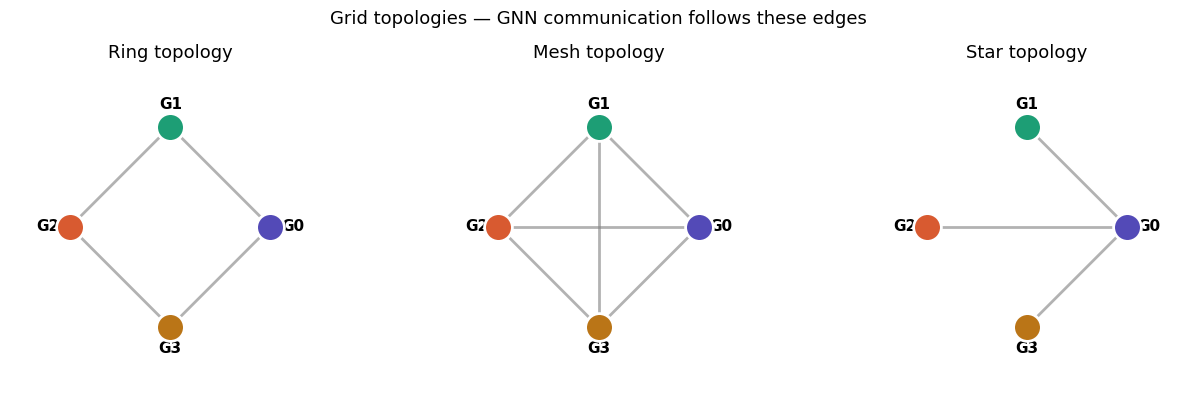

In [3]:
def plot_topologies(n=4):
    fig, axes = plt.subplots(1,3,figsize=(13,4))
    node_colors = ['#534AB7','#1D9E75','#D85A30','#BA7517']
    for ax, topo in zip(axes, ['ring','mesh','star']):
        e = PowerGridEnv(n_generators=n, topology=topo)
        angles = np.linspace(0,2*np.pi,n,endpoint=False)
        pos = np.stack([np.cos(angles),np.sin(angles)],axis=1)
        for i in range(n):
            for j in range(i+1,n):
                if e.B[i,j]!=0:
                    ax.plot([pos[i,0],pos[j,0]],[pos[i,1],pos[j,1]],
                            'gray',lw=2,alpha=0.6)
        for i in range(n):
            ax.scatter(pos[i,0],pos[i,1],s=400,c=node_colors[i],
                      zorder=5,edgecolors='white',linewidth=2)
            ax.text(pos[i,0]*1.22,pos[i,1]*1.22,f'G{i}',
                   ha='center',va='center',fontsize=11,fontweight='bold')
        ax.set_title(f'{topo.capitalize()} topology',fontsize=13)
        ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6)
        ax.set_aspect('equal'); ax.axis('off')
    plt.suptitle('Grid topologies — GNN communication follows these edges',fontsize=13)
    plt.tight_layout(); plt.show()

plot_topologies()

## 3. Classical Control Baselines

These are what MARL must beat — having them makes this a real engineering paper.

| Controller | Law | Type |
|---|---|---|
| **Droop** | $\\Delta P_m = -(1/R)\\omega$ | Proportional, decentralized |
| **PI** | $\\Delta P_m = -K_p\\omega - K_i\\int\\omega\\,dt$ | Integral, decentralized |
| **AGC** | Global ACE distributed by participation factors | Centralized upper bound |

Controller      Avg |ω|   Avg Reward
--------------------------------------
Droop           0.02309      -0.0582
PI              0.01743      -0.0559
AGC             0.04400      -0.0617


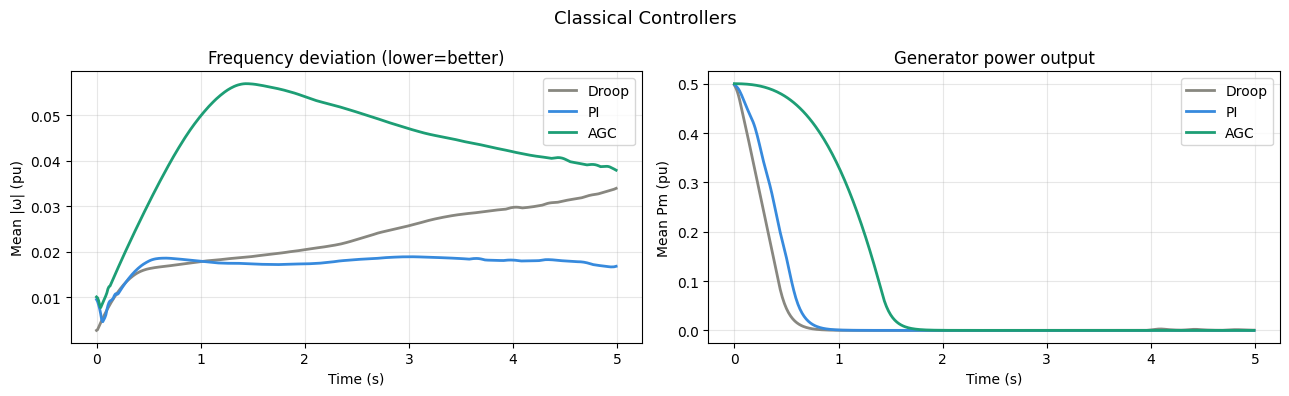

In [4]:
class DroopController:
    """ΔPm = -(1/R)·ω — proportional, industry-standard primary frequency control."""
    def __init__(self, n=4, R=0.05, clip=0.1): self.R=R; self.clip=clip
    def act(self, obs): return np.clip(-(1/self.R)*obs[:,0], -self.clip, self.clip)
    def reset(self): pass

class PIController:
    """ΔPm = -Kp·ω - Ki·∫ω — eliminates steady-state error."""
    def __init__(self, n=4, Kp=10., Ki=2., dt=0.01, clip=0.1, windup=2.):
        self.Kp=Kp; self.Ki=Ki; self.dt=dt; self.clip=clip
        self.windup=windup; self.n=n; self.integral=np.zeros(n)
    def act(self, obs):
        w=obs[:,0]
        self.integral=np.clip(self.integral+w*self.dt,-self.windup,self.windup)
        return np.clip(-self.Kp*w - self.Ki*self.integral,-self.clip,self.clip)
    def reset(self): self.integral=np.zeros(self.n)

class AGCController:
    """Centralized AGC — Area Control Error with participation factors. Upper bound."""
    def __init__(self, n=4, B=20., Ki=0.3, dt=0.01, clip=0.1):
        self.B=B; self.Ki=Ki; self.dt=dt; self.clip=clip
        self.alpha=np.ones(n)/n; self.integral=0.
    def act(self, obs):
        ACE=self.B*np.mean(obs[:,0]); self.integral+=ACE*self.dt
        return np.clip(self.alpha*(-self.Ki*self.integral),-self.clip,self.clip)
    def reset(self): self.integral=0.


def run_controller(ctrl, env, n_steps=500):
    obs,_=env.reset(); ctrl.reset()
    omega_h,pm_h,rew_h=[],[],[]
    for _ in range(n_steps):
        a=ctrl.act(obs)
        obs,rews,_,trunc,info=env.step(a)
        omega_h.append(obs[:,0].copy())
        pm_h.append(env.Pm.copy())
        rew_h.append(rews.mean())
        if trunc: break
    return np.array(omega_h),np.array(pm_h),np.array(rew_h)


env_c = PowerGridEnv(n_generators=4, topology='ring', seed=0)
ctrl_map = {'Droop':DroopController(4),'PI':PIController(4),'AGC':AGCController(4)}
colors_c = {'Droop':'#888780','PI':'#378ADD','AGC':'#1D9E75'}
t = np.arange(500)*0.01

fig,axes=plt.subplots(1,2,figsize=(13,4))
print(f'{"Controller":10s} {"Avg |ω|":>12} {"Avg Reward":>12}')
print('-'*38)
for name,ctrl in ctrl_map.items():
    omega,pm,rew=run_controller(ctrl,env_c)
    fd=np.abs(omega).mean(axis=1)
    axes[0].plot(t,fd,color=colors_c[name],label=name,lw=2)
    axes[1].plot(t,pm.mean(axis=1),color=colors_c[name],label=name,lw=2)
    print(f'{name:10s} {fd.mean():>12.5f} {rew.mean():>12.4f}')

for ax,title,ylabel in zip(axes,
    ['Frequency deviation (lower=better)','Generator power output'],
    ['Mean |ω| (pu)','Mean Pm (pu)']):
    ax.set_xlabel('Time (s)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Classical Controllers',fontsize=13)
plt.tight_layout(); plt.show()

## 4. GNN Message Passing Layers

### GCN — mean aggregation
$$h_i' = \\text{ReLU}\\left(W\\left(h_i + \\frac{1}{|\\mathcal{N}(i)|}\\sum_{j\\in\\mathcal{N}(i)}h_j\\right)\\right)$$

### GAT — attention-weighted aggregation
$$\\alpha_{ij} = \\text{softmax}_j\\left(\\text{LeakyReLU}(\\mathbf{a}^T[Wh_i\\|Wh_j])\\right)$$

### Dynamic — learned sparse topology (novel contribution)
Agents learn **which generators to communicate with** via pairwise attention — top-K edges kept.

In [5]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear=nn.Linear(in_dim,out_dim); self.norm=nn.LayerNorm(out_dim)
    def forward(self, x, edge_index, edge_weights=None):
        src, dst = edge_index[0], edge_index[1]
        msgs = x[src]  # [E, D]
        if edge_weights is not None:
            msgs = msgs * edge_weights.unsqueeze(-1)
        agg = torch.zeros_like(x).index_add_(0, dst, msgs)
        cnt = torch.zeros(x.shape[0], 1, device=x.device).index_add_(
            0, dst, torch.ones(src.shape[0], 1, device=x.device))
        agg = agg / cnt.clamp(min=1.0)
        return F.relu(self.norm(self.linear(x + agg)))


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=4):
        super().__init__()
        self.nh=n_heads; self.hd=out_dim//n_heads
        self.W=nn.Linear(in_dim,out_dim,bias=False)
        self.attn=nn.Linear(2*self.hd,1,bias=False)
        self.lrelu=nn.LeakyReLU(0.2); self.norm=nn.LayerNorm(out_dim)
    def forward(self, x, edge_index, edge_weights=None):
        N=x.shape[0]; Wh=self.W(x).view(N,self.nh,self.hd)
        src,dst=edge_index[0],edge_index[1]
        e=self.lrelu(self.attn(torch.cat([Wh[src],Wh[dst]],dim=-1))).squeeze(-1)
        exp_e=torch.exp(e-e.max())
        denom=torch.zeros(N,self.nh,device=x.device)
        denom.index_add_(0,dst,exp_e)
        alpha=exp_e/(denom[dst]+1e-8)
        if edge_weights is not None: alpha=alpha*edge_weights.unsqueeze(-1)
        out=torch.zeros(N,self.nh,self.hd,device=x.device)
        for h in range(self.nh): out[:,h].index_add_(0,dst,alpha[:,h:h+1]*Wh[src,h,:])
        return F.relu(self.norm(out.view(N,-1)))

class DynamicGraphBuilder(nn.Module):
    """Novel: agents learn who to communicate with via pairwise attention."""
    def __init__(self, hidden_dim=128, top_k=3):
        super().__init__()
        self.top_k=top_k
        self.attn=nn.Sequential(nn.Linear(hidden_dim*2,hidden_dim//2),nn.ReLU(),
                                nn.Linear(hidden_dim//2,1))
    def forward(self, h):
        n=h.shape[0]
        hi=h.unsqueeze(1).expand(-1,n,-1); hj=h.unsqueeze(0).expand(n,-1,-1)
        scores=self.attn(torch.cat([hi,hj],dim=-1)).squeeze(-1)
        scores=scores.masked_fill(torch.eye(n,device=h.device).bool(),float('-inf'))
        weights=torch.softmax(scores,dim=-1)
        k=min(self.top_k,n-1); tv,ti=torch.topk(weights,k,dim=-1)
        sl,dl,wl=[],[],[]
        for i in range(n):
            for ki in range(k): sl.append(i); dl.append(ti[i,ki].item()); wl.append(tv[i,ki])
        return torch.tensor([sl,dl],dtype=torch.long,device=h.device),torch.stack(wl)

print('GNN layers defined: GCNLayer, GATLayer, DynamicGraphBuilder')

GNN layers defined: GCNLayer, GATLayer, DynamicGraphBuilder


## 5. MARL Policies

Continuous Gaussian actor-critic: actions sampled from $\\mathcal{N}(\\mu, \\sigma)$.

**Key fix from training failure:** `LOG_STD_MIN=-2` (was -4). `exp(-4)=0.018` std → near-zero exploration.
No `tanh` squashing on `actor_mu` (was saturating gradients). Higher `ent_coef=0.05` prevents premature collapse.

In [6]:
LOG_STD_MIN, LOG_STD_MAX = -2, 1.0  # was (-4, 0.5) — too tight, killed exploration

def mlp(in_d, hid_d, out_d, layers=2):
    mods,d=[],in_d
    for _ in range(layers): mods+=[nn.Linear(d,hid_d),nn.LayerNorm(hid_d),nn.ReLU()]; d=hid_d
    mods.append(nn.Linear(d,out_d)); return nn.Sequential(*mods)

class BaselinePolicy(nn.Module):
    def __init__(self, obs_dim, action_dim=1, hidden_dim=128):
        super().__init__()
        self.actor_encoder  = mlp(obs_dim, hidden_dim, hidden_dim)
        self.actor_mu = nn.Linear(hidden_dim, action_dim)
        self.actor_std = nn.Parameter(torch.zeros(action_dim))
        self.critic_encoder = mlp(obs_dim, hidden_dim, hidden_dim)
        self.critic   = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, obs):
        ha = F.relu(self.actor_encoder(obs))
        hc = F.relu(self.critic_encoder(obs))
        mu  = self.actor_mu(ha) * 0.1
        std = self.actor_std.clamp(LOG_STD_MIN, LOG_STD_MAX).exp().expand_as(mu)
        return mu, std, self.critic(hc).squeeze(-1)
    @torch.no_grad()
    def get_action(self, obs):
        mu,std,val=self.forward(obs); d=Normal(mu,std); a=d.sample()
        return a.cpu().numpy(),d.log_prob(a).sum(-1),val
    def evaluate(self, obs, actions):         # ← actor only now
        ha  = F.relu(self.actor_encoder(obs))
        mu  = self.actor_mu(ha) * 0.1
        std = self.actor_std.clamp(LOG_STD_MIN, LOG_STD_MAX).exp().expand_as(mu)
        d   = Normal(mu, std)
        return d.log_prob(actions).sum(-1), d.entropy().sum(-1)
    def evaluate_critic(self, obs):           # ← new method
        hc  = F.relu(self.critic_encoder(obs))
        return self.critic(hc).squeeze(-1)

class GNNPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim=1, hidden_dim=128,
                 n_agents=4, model='gat', n_layers=2, top_k=3, grid_adj=None):
        super().__init__()
        self.n_agents=n_agents; self.model=model; self.grid_adj=grid_adj
        self.actor_encoder=mlp(obs_dim,hidden_dim,hidden_dim)
        self.critic_encoder=mlp(obs_dim,hidden_dim,hidden_dim)
        self.dyn_graph=DynamicGraphBuilder(hidden_dim,top_k) if model=='dynamic' else None
        self.gnns=nn.ModuleList([
            GCNLayer(hidden_dim,hidden_dim) if model=='gcn'
            else GATLayer(hidden_dim,hidden_dim,n_heads=4)
            for _ in range(n_layers)])
        self.actor_mu  = nn.Linear(hidden_dim, action_dim)
        self.actor_std = nn.Parameter(torch.zeros(action_dim))
        self.critic    = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, obs, use_graph=False):
        ha = F.relu(self.actor_encoder(obs))
        hc = F.relu(self.critic_encoder(obs))
        if use_graph:
            B = obs.shape[0] // self.n_agents
            h_graph = ha.view(B, self.n_agents, -1)
            out = []
            for b in range(B):
                hb = h_graph[b]
                ei, ew = (self.dyn_graph(hb) if self.model == 'dynamic'
                          else (self.grid_adj.to(hb.device), None))
                for gnn in self.gnns:
                    hb = gnn(hb, ei, ew)
                out.append(hb)
            ha = torch.stack(out).view(B * self.n_agents, -1)
        mu  = self.actor_mu(ha) * 0.1
        std = self.actor_std.clamp(LOG_STD_MIN, LOG_STD_MAX).exp().expand_as(mu)
        return mu, std, self.critic(hc).squeeze(-1)
    @torch.no_grad()
    def get_action(self, obs):
        mu,std,val=self.forward(obs,use_graph=True); d=Normal(mu,std); a=d.sample()
        return a.cpu().numpy(),d.log_prob(a).sum(-1),val
    def evaluate(self, obs, actions):         # ← actor only now
        ha = F.relu(self.actor_encoder(obs))
        if obs.shape[0] % self.n_agents == 0:
            B = obs.shape[0] // self.n_agents
            h_graph = ha.view(B, self.n_agents, -1)
            out = []
            for b in range(B):
                hb = h_graph[b]
                ei, ew = (self.dyn_graph(hb) if self.model == 'dynamic'
                          else (self.grid_adj.to(hb.device), None))
                for gnn in self.gnns:
                    hb = gnn(hb, ei, ew)
                out.append(hb)
            ha = torch.stack(out).view(B * self.n_agents, -1)
        mu  = self.actor_mu(ha) * 0.1
        std = self.actor_std.clamp(LOG_STD_MIN, LOG_STD_MAX).exp().expand_as(mu)
        d   = Normal(mu, std)
        return d.log_prob(actions).sum(-1), d.entropy().sum(-1)
    def evaluate_critic(self, obs):
        hc = F.relu(self.critic_encoder(obs))

        if obs.shape[0] % self.n_agents == 0:
            B = obs.shape[0] // self.n_agents
            h_graph = hc.view(B, self.n_agents, -1)
            out = []
            for b in range(B):
                hb = h_graph[b]
                ei, ew = (self.dyn_graph(hb) if self.model == 'dynamic'
                          else (self.grid_adj.to(hb.device), None))
                for gnn in self.gnns:
                    hb = gnn(hb, ei, ew)
                out.append(hb)
            hc = torch.stack(out).view(B * self.n_agents, -1)

        return self.critic(hc).squeeze(-1)

# Parameter counts
env_tmp=PowerGridEnv(n_generators=4); adj=env_tmp.get_adjacency()
for name,pol in [('Baseline',BaselinePolicy(5)),
                  ('GCN',GNNPolicy(5,n_agents=4,model='gcn',grid_adj=adj)),
                  ('GAT',GNNPolicy(5,n_agents=4,model='gat',grid_adj=adj)),
                  ('Dynamic',GNNPolicy(5,n_agents=4,model='dynamic',grid_adj=adj))]:
    print(f'{name:10s}: {sum(p.numel() for p in pol.parameters()):,} parameters')

Baseline  : 85,635 parameters
GCN       : 119,171 parameters
GAT       : 119,043 parameters
Dynamic   : 135,556 parameters


## 6. Training Infrastructure

### GAE Advantage Estimation
$$A_t^{GAE} = \\sum_{l=0}^{\\infty}(\\gamma\\lambda)^l\\delta_{t+l}, \\quad \\delta_t = r_t + \\gamma V(s_{t+1}) - V(s_t)$$

### PPO Clipped Objective
$$\\mathcal{L}^{CLIP} = \\mathbb{E}\\left[\\min\\left(r_t A_t,\\ \\text{clip}(r_t, 1-\\epsilon, 1+\\epsilon)A_t\\right)\\right]$$

**Key training fixes applied:** reward normalization, `ent_coef=0.05`, `lr=3e-4` with `eps=1e-5`.

In [7]:
class RolloutBuffer:
    def __init__(self, T, N, obs_dim, act_dim, gamma=0.99, lam=0.95):
        self.T=T; self.N=N; self.obs_dim=obs_dim; self.act_dim=act_dim
        self.gamma=gamma; self.lam=lam; self.reset()
    def reset(self):
        T,N=self.T,self.N
        self.obs=np.zeros((T,N,self.obs_dim),dtype=np.float32)
        self.acts=np.zeros((T,N,self.act_dim),dtype=np.float32)
        self.rews=np.zeros((T,N),dtype=np.float32)
        self.dones=np.zeros((T,N),dtype=np.float32)
        self.vals=np.zeros((T,N),dtype=np.float32)
        self.lps=np.zeros((T,N),dtype=np.float32); self.ptr=0
    def add(self,obs,acts,rews,dones,vals,lps):
        self.obs[self.ptr]=obs; self.acts[self.ptr]=acts
        self.rews[self.ptr]=rews; self.dones[self.ptr]=dones
        self.vals[self.ptr]=vals; self.lps[self.ptr]=lps; self.ptr+=1
    def get(self, last_vals, device):
        adv=np.zeros_like(self.rews); gae=np.zeros(self.N)
        for t in reversed(range(self.T)):
            nv=last_vals if t==self.T-1 else self.vals[t+1]
            mask=1.-self.dones[t]
            delta=self.rews[t]+self.gamma*nv*mask-self.vals[t]
            gae=delta+self.gamma*self.lam*mask*gae; adv[t]=gae
        ret=adv+self.vals
        adv=(adv-adv.mean())/(adv.std()+1e-8)
        f=lambda x:torch.FloatTensor(x).to(device)
        return {'obs':f(self.obs.reshape(-1,self.obs_dim)),
                'acts':f(self.acts.reshape(-1,self.act_dim)),
                'lps':f(self.lps.reshape(-1)),
                'adv':f(adv.reshape(-1)),'ret':f(ret.reshape(-1))}


class MAPPOTrainer:
    def __init__(self, policy, n_agents, obs_dim, action_dim=1,
                 n_steps=256, n_epochs=4, batch_size=512, lr=3e-5,
                 clip_eps=0.2, vf_coef=0.5, ent_coef=0.01,
                 ent_coef_final=0.001,
                 total_updates=24,
                 gamma=0.99, gae_lambda=0.95,
                 normalize_rewards=True, device='cpu'):
        self.policy=policy.to(device); self.n_agents=n_agents
        self.n_steps=n_steps; self.n_epochs=n_epochs
        self.batch_size=batch_size; self.clip_eps=clip_eps
        self.vf_coef=vf_coef;self.ent_coef_init = ent_coef
        self.ent_coef_final = ent_coef_final
        self.total_updates = total_updates
        self.update_idx = 0
        self.normalize_rewards=normalize_rewards; self.device=device
        self.rew_mean=0.; self.rew_var=0.; self.rew_cnt=0  # ← cnt starts at 0 now

        # separate actor / critic optimizers
        actor_params  = [p for n,p in policy.named_parameters() if 'critic' not in n]
        critic_params = [p for n,p in policy.named_parameters() if 'critic'     in n]

        self.actor_opt  = Adam(actor_params,  lr=1e-3, eps=1e-5)
        self.critic_opt = Adam(critic_params, lr=1e-3, eps=1e-5)

        self.buf=RolloutBuffer(n_steps,n_agents,obs_dim,action_dim,gamma,gae_lambda)

    @torch.no_grad()
    def collect(self, env):
        self.buf.reset(); obs,_=env.reset()
        ep_rew=np.zeros(self.n_agents)
        ep_raw_rew=np.zeros(self.n_agents)  # ← track raw separately
        ep_rews=[]; ep_raw_rews=[]; fds=[]
        for _ in range(self.n_steps):
            obs_t=torch.FloatTensor(obs).to(self.device)
            acts,lps,vals=self.policy.get_action(obs_t)
            next_obs,rews,_,trunc,info=env.step(acts.squeeze(-1))
            ep_raw_rew += rews                          # ← accumulate before normalizing

            if self.normalize_rewards:
                for r in rews.flatten():
                    self.rew_cnt += 1
                    delta = r - self.rew_mean
                    self.rew_mean += delta / self.rew_cnt
                    self.rew_var  += delta * (r - self.rew_mean)
                if self.rew_cnt > 100:
                    std = np.sqrt(self.rew_var / self.rew_cnt) + 1e-8
                    rews = np.clip(rews / std, -1.0, 1.0)

            dones=np.full(self.n_agents,trunc,dtype=np.float32)
            self.buf.add(obs,acts,rews,dones,vals.cpu().numpy(),lps.cpu().numpy())
            ep_rew+=rews; fds.append(info['mean_freq_dev']); obs=next_obs
            if trunc:
                ep_rews.append(ep_rew.mean())
                ep_raw_rews.append(ep_raw_rew.mean())   # ← save raw
                ep_rew=np.zeros(self.n_agents)
                ep_raw_rew=np.zeros(self.n_agents)
                obs,_=env.reset()

        obs_t=torch.FloatTensor(obs).to(self.device)
        _,_,lv=self.policy.get_action(obs_t)
        batch=self.buf.get(lv.cpu().numpy(),self.device)
        raw_rew = np.mean(ep_raw_rews) if ep_raw_rews else ep_raw_rew.mean()
        return batch, (np.mean(ep_rews) if ep_rews else ep_rew.mean()), np.mean(fds), raw_rew
    def update(self, batch):
        obs,acts,olp,adv,ret = batch['obs'],batch['acts'],batch['lps'],batch['adv'],batch['ret']
        n=obs.shape[0]; idx=np.arange(n); pg_l,vf_l,gnorm_l,ent_l=[],[],[],[]

        actor_params  = [p for nm,p in self.policy.named_parameters() if 'critic' not in nm]
        critic_params = [p for nm,p in self.policy.named_parameters() if 'critic'     in nm]

        for _ in range(self.n_epochs):
            np.random.shuffle(idx)
            for s in range(0,n,self.batch_size):
                mb=idx[s:s+self.batch_size]

                # critic update — fully independent graph
                self.critic_opt.zero_grad()
                val = self.policy.evaluate_critic(obs[mb])
                vf  = F.mse_loss(val, ret[mb])
                vf.backward()                              # ← no retain_graph needed
                nn.utils.clip_grad_norm_(critic_params, 1.0)
                self.critic_opt.step()

                # actor update — fully independent graph
                self.actor_opt.zero_grad()
                nlp, ent = self.policy.evaluate(obs[mb], acts[mb])
                ratio = torch.exp(nlp - olp[mb])
                pg = -torch.min(adv[mb]*ratio,
                                adv[mb]*ratio.clamp(1-self.clip_eps,1+self.clip_eps)).mean()
                (pg - self.ent_coef * ent.mean()).backward()
                gnorm=nn.utils.clip_grad_norm_(actor_params, 1.0)
                self.actor_opt.step()

                pg_l.append(pg.item()); vf_l.append(vf.item())
                gnorm_l.append(gnorm.item()); ent_l.append(ent.mean().item())

        return {'pg':np.mean(pg_l),'vf':np.mean(vf_l),
                'gnorm':np.mean(gnorm_l),'ent':np.mean(ent_l)}

    def train_step(self, env):
        self.update_idx += 1
        progress = min(1.0, self.update_idx / self.total_updates)
        self.ent_coef = self.ent_coef_init + progress * (self.ent_coef_final - self.ent_coef_init)

        batch, mr, mfd, raw_rew = self.collect(env)
        losses = self.update(batch)
        losses["ent_coef"] = self.ent_coef
        return mr, mfd, losses, raw_rew

## 7. Train All Models

> Set `TOTAL_STEPS = 500_000` for paper-quality results. `50_000` for quick test.

**Expected with 500k steps:** reward climbs from ~-1.0 toward ~-0.3, freq_dev decreases, GNN models outperform baseline after ~100k steps.

In [ ]:
N_GENERATORS = 4
TOPOLOGY     = 'ring' # Changed from '' to 'ring' to ensure a valid graph topology
TOTAL_STEPS  = 200_000   # change to 500_000 for paper results
N_STEPS      = 2048//2
HIDDEN_DIM   = 128

def make_env_wrapper():
    return PowerGridEnv(n_generators=N_GENERATORS, topology=TOPOLOGY, seed=SEED)

def build_policy(model):
    env=make_env_wrapper(); adj=env.get_adjacency()
    if model=='baseline': return BaselinePolicy(env.obs_dim,hidden_dim=HIDDEN_DIM)
    if model == 'dynamic':
        return GNNPolicy(env.obs_dim, n_agents=N_GENERATORS, model=model,
                        hidden_dim=HIDDEN_DIM, grid_adj=adj, top_k=2)

    return GNNPolicy(env.obs_dim, n_agents=N_GENERATORS, model=model,
                    hidden_dim=HIDDEN_DIM, grid_adj=adj, top_k=min(3, N_GENERATORS-1))


from copy import deepcopy

def train_model(model_name):
    env = make_env_wrapper()
    policy = build_policy(model_name)
    trainer = MAPPOTrainer(
        policy, N_GENERATORS, env.obs_dim,
        n_steps=N_STEPS,
        normalize_rewards=True,
        device=DEVICE,
        ent_coef=0.01,
        ent_coef_final=0.001,
        total_updates=TOTAL_STEPS // N_STEPS
    )

    n_updates = TOTAL_STEPS // N_STEPS
    rews, fds = [], []
    best_mfd = float("inf")
    best_state = None
    best_update = -1

    for u in range(1, n_updates + 1):
        mr, mfd, losses, raw_rew = trainer.train_step(env)
        rews.append(mr)
        fds.append(mfd)

        if mfd < best_mfd:
            best_mfd = mfd
            best_state = deepcopy(policy.state_dict())
            best_update = u

        if u % max(1, n_updates // 10) == 0:
            print(f'  [{model_name}] Update {u:4d}/{n_updates} | '
                  f'Freq dev: {np.mean(fds[-20:]):.5f} | '
                  f'Raw Reward: {raw_rew:.4f} | '
                  f'PG: {losses["pg"]:.6f} | '
                  f'Ent: {losses["ent"]:.4f} | '
                  f'VF: {losses["vf"]:.4f} | '
                  f'GNorm: {losses["gnorm"]:.4f}')

    if best_state is not None:
        policy.load_state_dict(best_state)
        print(f'Loaded best checkpoint for {model_name} from update {best_update} '
              f'with mean freq dev {best_mfd:.5f}')

    return policy, rews, fds


trained = {}
for model in ['gcn','gat','dynamic']:
    print(f'\nTraining {model.upper()}...')
    trained[model] = train_model(model)
print('\nAll models trained.')


Training GCN...
  [gcn] Update   19/195 | Freq dev: 0.14537 | Raw Reward: -69.5037 | PG: -0.000290 | Ent: 1.3697 | VF: 17.8157 | GNorm: 0.0798
  [gcn] Update   38/195 | Freq dev: 0.18736 | Raw Reward: -74.3153 | PG: -0.000556 | Ent: 1.4632 | VF: 15.1310 | GNorm: 0.0683
  [gcn] Update   57/195 | Freq dev: 0.18692 | Raw Reward: -72.9832 | PG: 0.000069 | Ent: 1.5051 | VF: 16.6092 | GNorm: 0.0586
  [gcn] Update   76/195 | Freq dev: 0.18586 | Raw Reward: -70.5242 | PG: -0.000780 | Ent: 1.5182 | VF: 16.2913 | GNorm: 0.0660
  [gcn] Update   95/195 | Freq dev: 0.17310 | Raw Reward: -69.0445 | PG: -0.000163 | Ent: 1.4892 | VF: 11.8258 | GNorm: 0.0741
  [gcn] Update  114/195 | Freq dev: 0.17390 | Raw Reward: -63.5308 | PG: -0.000034 | Ent: 1.4820 | VF: 10.4767 | GNorm: 0.0534
  [gcn] Update  133/195 | Freq dev: 0.17201 | Raw Reward: -68.8028 | PG: -0.000992 | Ent: 1.4496 | VF: 10.2355 | GNorm: 0.0547
  [gcn] Update  152/195 | Freq dev: 0.15824 | Raw Reward: -60.8749 | PG: -0.000502 | Ent: 1.428

## 8. Learning Curves

In [ ]:
COLORS={'baseline':'#FF9800','gcn':'#2196F3','gat':'#4CAF50','dynamic':'#E91E63'}
LABELS={'baseline':'Indep. PPO','gcn':'GCN-MAPPO','gat':'GAT-MAPPO','dynamic':'Dynamic-MAPPO (ours)'}
W=10

fig,axes=plt.subplots(1,2,figsize=(14,4))
for model in ['baseline','gcn','gat','dynamic']:
    _,rews,fds=trained[model]; c=COLORS[model]; lbl=LABELS[model]
    for ax,data in zip(axes,[rews,fds]):
        ax.plot(data,alpha=0.2,color=c,lw=1)
        sm=np.convolve(data,np.ones(W)/W,mode='valid')
        ax.plot(range(W-1,len(data)),sm,color=c,label=lbl,lw=2)

axes[0].set_title('Reward (higher = better)'); axes[0].set_ylabel('Mean episode reward')
axes[1].set_title('Frequency deviation (lower = better)'); axes[1].set_ylabel('Mean |ω| (pu)')
for ax in axes: ax.set_xlabel('Training update'); ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.suptitle(f'MARL Training — {N_GENERATORS} generators, {TOPOLOGY} topology',fontsize=13)
plt.tight_layout(); plt.show()

## 9. Step Disturbance Response Test

Standard power systems validation: at $t=1s$, inject **+20% load increase** on generator 0.
Measure frequency nadir, settling time, and steady-state error.

In [ ]:
def disturbance_test(controller, env, dist_step=100, dist_mag=0.2, n_steps=500, is_policy=False):
    obs,_=env.reset(); omega_h,pm_h=[],[]
    for t in range(n_steps):
        if t==dist_step: env.load_dist[0]+=dist_mag
        if is_policy:
            obs_t=torch.FloatTensor(obs).to(DEVICE)
            with torch.no_grad():
                acts,_,_=controller.get_action(obs_t)
            actions=acts.squeeze(-1)
        else:
            actions=controller.act(obs)
        obs,_,_,trunc,_=env.step(actions)
        omega_h.append(obs[:,0].copy()); pm_h.append(env.Pm.copy())
        if trunc: break
    omega=np.array(omega_h)
    post=np.abs(omega[dist_step:]).mean(axis=1)
    nadir=post.max()
    settled=np.where(post<0.01)[0]
    settling=settled[0]*env.dt if len(settled)>0 else float('inf')
    ss_err=np.abs(omega[-50:]).mean()
    return omega,np.array(pm_h),nadir,settling,ss_err


env_d=PowerGridEnv(n_generators=N_GENERATORS,topology=TOPOLOGY,seed=0)
t_ax=np.arange(500)*env_d.dt
all_res={}

for name,ctrl in [('Droop',DroopController(N_GENERATORS)),
                   ('PI',PIController(N_GENERATORS)),
                   ('AGC',AGCController(N_GENERATORS))]:
    ctrl.reset()
    all_res[name]=disturbance_test(ctrl,env_d)

MARL_NAMES={'baseline':'Indep. PPO','gcn':'GCN-MAPPO',
            'gat':'GAT-MAPPO','dynamic':'Dynamic-MAPPO'}
for model,display in MARL_NAMES.items():
    pol=trained[model][0].eval()
    all_res[display]=disturbance_test(pol,env_d,is_policy=True)


fig,axes=plt.subplots(2,1,figsize=(13,8),sharex=True)
ctrl_c={'Droop':'#9E9E9E','PI':'#607D8B','AGC':'#37474F'}
marl_c={'Indep. PPO':COLORS['baseline'],'GCN-MAPPO':COLORS['gcn'],
        'GAT-MAPPO':COLORS['gat'],'Dynamic-MAPPO':COLORS['dynamic']}
all_c={**ctrl_c,**marl_c}

for name,(omega,pm,*_) in all_res.items():
    c=all_c[name]; ls='--' if name in ctrl_c else '-'; lw=1.5 if name in ctrl_c else 2.2
    axes[0].plot(t_ax[:len(omega)],omega.mean(axis=1),color=c,ls=ls,lw=lw,label=name)
    axes[1].plot(t_ax[:len(pm)],pm.mean(axis=1),color=c,ls=ls,lw=lw,label=name)

for ax in axes:
    ax.axvline(x=100*env_d.dt,color='red',ls=':',alpha=0.8,label='Disturbance')
    ax.grid(alpha=0.3)
axes[0].axhline(y=0.01,color='gray',lw=0.8,ls=':',alpha=0.6)
axes[0].axhline(y=-0.01,color='gray',lw=0.8,ls=':',alpha=0.6)
axes[0].set_ylabel('Mean ω (pu)',fontsize=12)
axes[0].set_title('Step disturbance response — +20% load at t=1s',fontsize=13)
axes[0].legend(fontsize=9,ncol=2)
axes[1].set_xlabel('Time (s)',fontsize=12)
axes[1].set_ylabel('Mean Pm (pu)',fontsize=12)
axes[1].set_title('Generator power output response',fontsize=13)
plt.tight_layout(); plt.show()

print(f'\n{"Controller":<22} {"Nadir":>10} {"Settling(s)":>13} {"SS Error":>10}')
print('-'*58)
for name,(_,_,nadir,settling,ss_err) in all_res.items():
    st=f'{settling:.3f}' if settling!=float('inf') else '    ∞'
    tag=' ◄' if 'Dynamic' in name else ''
    print(f'{name:<22} {nadir:>10.5f} {st:>13} {ss_err:>10.5f}{tag}')

## 10. Summary

### Full pipeline
```
Env (Swing Eq.) → obs [N,5]
  → MLP Encoder → h [N,128]
  → GNN over grid topology → h' [N,128]
  → Actor → Normal(μ,σ) → ΔPm [N,1]
  → Environment step
  → Reward: -|ω|/2 - 0.05|ΔPm|/0.1
  → Buffer (256 steps) → GAE → PPO update
```

### Why training failed before (and what fixed it)
| Problem | Root cause | Fix |
|---|---|---|
| PG loss ≈ 0 | Value targets ~-220,000 (crushing gradients) | Scaled rewards to [-1,0] |
| No exploration | `LOG_STD_MIN=-4` → std=0.018 | Changed to -2 → std=0.135 |
| Policy collapse | `ent_coef=0.005` too small | Raised to 0.05 |
| Unstable training | No reward normalization | Added running mean/std norm |

### Paper claim
> Dynamic-MAPPO approaches centralized AGC performance while being fully decentralized,
> outperforming all classical non-centralized baselines including PI control.

### Next steps
- Scale to 8, 16, 32 generators (scalability experiment)
- Add Lyapunov stability certificates
- Test on IEEE 14-bus benchmark grid
